# HOMEWORK4
Consider a single-degree-of-freedom spring-mass-damper system with mass $m = 3 kg$, undamped
natural circular frequency $\omega_n = 16 rad/s$ and damping ratio $\zeta$ = 0.06. The system is subjected to an
excitation force $f(t)$ that consists of a sequence of two half-sine pulses, as shown in the figure below.

The first pulse has a height magnitude of 5 N and a frequency $\omega_1 = 13 rad/s$, and starts from zero
at time $t= 0$ seconds. The second pulse has a height magnitude of 11 N and a frequency of $\omega_2 = 20
rad/s$. The second pulse starts from zero at $t= T1$, where $T1 =\frac{2π}{\omega_1}$ is the period of a full oscillation
at frequency $\omega_1$.

Convolutional integral:
$$x(t) = \int_0^t f(\tau) g(t-\tau) d\tau$$
Where $f(t)$ is excitation. From equation 4.13, impulse response is:
$$g(t) =\frac{1}{2 im\omega_d} e^{-\zeta \omega_n t}(e^{i\omega_d t}-e^{-i\omega_d t}) =\frac{1}{m\omega_d} e^{-\zeta \omega_n t} sin\omega_d t$$

In [15]:
from sympy import (exp, integrate, symbols, expand, plot, pi, sin,
simplify, sqrt)
t, tau = symbols('t, tau',real = True)


omega1 = 13 # rad/s
omega2 = 20 # rad/s
F1 = 5 # N
F3 = 11 # N
omega_n = 16 # rad/s
zeta = 0.06
omega_d = sqrt(1 - zeta*zeta)*omega_n
m = 3 # kg
k = omega_n*omega_n*m
c = 2*zeta*omega_n*m
T1 = 2*pi/omega1
T2 = 2*pi/omega2
F2 = F3*exp(-1j*omega2*T1)

In [16]:
f1 = 1j*F1/2*exp(1j*omega1*t) - 1j*F1/2*exp(-1j*omega1*t)
print('f1 = ',f1)
f1

f1 =  2.5*I*exp(13.0*I*t) - 2.5*I*exp(-13.0*I*t)


2.5*I*exp(13.0*I*t) - 2.5*I*exp(-13.0*I*t)

In [17]:
ftau1 = f1.subs(t,tau)
print('ftau1 = ',ftau1)
ftau1

ftau1 =  2.5*I*exp(13.0*I*tau) - 2.5*I*exp(-13.0*I*tau)


2.5*I*exp(13.0*I*tau) - 2.5*I*exp(-13.0*I*tau)

In [18]:
f2 = -1j*F2/2*exp(1j*omega2*t) + 1j*F2.conjugate()/2*exp(-1j*omega2*t)
print('f2 = ',f2)
f2

f2 =  -5.5*I*exp(-3.07692307692308*I*pi)*exp(20.0*I*t) + 5.5*I*exp(3.07692307692308*I*pi)*exp(-20.0*I*t)


-5.5*I*exp(-3.07692307692308*I*pi)*exp(20.0*I*t) + 5.5*I*exp(3.07692307692308*I*pi)*exp(-20.0*I*t)

In [19]:
ftau2 = f2.subs(t,tau)
print('ftau2 = ',ftau2)
ftau2

ftau2 =  -5.5*I*exp(-3.07692307692308*I*pi)*exp(20.0*I*tau) + 5.5*I*exp(3.07692307692308*I*pi)*exp(-20.0*I*tau)


-5.5*I*exp(-3.07692307692308*I*pi)*exp(20.0*I*tau) + 5.5*I*exp(3.07692307692308*I*pi)*exp(-20.0*I*tau)

In [20]:
g = -1j/2/m/omega_d*exp((-zeta*omega_n + 1j*omega_d)*t) + 1j/2/m/omega_d*exp((-zeta*omega_n - 1j*omega_d)*t)
print('g = ',g)
g

g =  0.0104354674440216*I*exp(t*(-0.96 - 15.9711740332388*I)) - 0.0104354674440216*I*exp(t*(-0.96 + 15.9711740332388*I))


0.0104354674440216*I*exp(t*(-0.96 - 15.9711740332388*I)) - 0.0104354674440216*I*exp(t*(-0.96 + 15.9711740332388*I))

In [21]:
gtmtau = g.subs(t,t-tau)
print('gtmtau = ',gtmtau)
gtmtau

gtmtau =  0.0104354674440216*I*exp((-0.96 - 15.9711740332388*I)*(t - tau)) - 0.0104354674440216*I*exp((-0.96 + 15.9711740332388*I)*(t - tau))


0.0104354674440216*I*exp((-0.96 - 15.9711740332388*I)*(t - tau)) - 0.0104354674440216*I*exp((-0.96 + 15.9711740332388*I)*(t - tau))

For $0\le t \le \frac{T_1}{2}$

In [22]:
x1 = integrate(ftau1*gtmtau,(tau,0,t))
x1 = simplify(x1)


For $\frac{T_1}{2} \le t \le T_1 $

In [23]:
x2 = integrate(ftau1*gtmtau,(tau,0,T1/2))
x2 = simplify(x2)

For $T_1 \le 𝑡 \le T_1+ \frac{T_2}{2} $

In [24]:
x3 = x2 + integrate(ftau2*gtmtau,(tau,T1,t))
x3 = simplify(x3)

For $ T_1 + \frac{T_2}{2} \le t $

In [29]:
x4 = x2 + integrate(ftau2*gtmtau,(tau,T1,T1+T2/2))
x4 = simplify(x4)

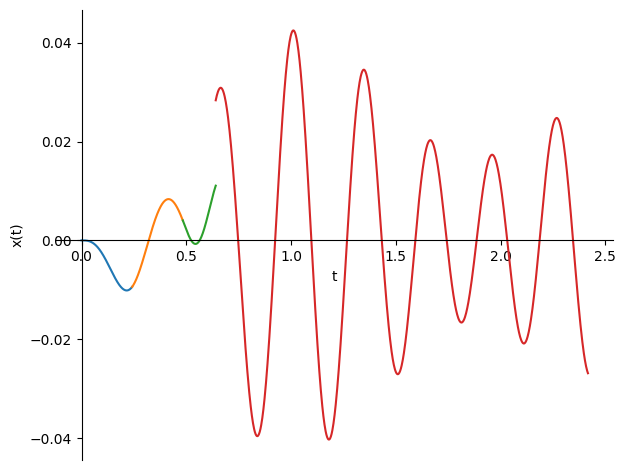

In [28]:
plot( (x1,(t,0,T1/2)), (x2,(t,T1/2,T1)), 
     (x3,(t,T1,T1+T2/2)),(x4,(t,T1+T2/2,5*T1)), xlabel='t',ylabel='x(t)',adaptive=False,nb_of_points=1000)